In [504]:
setwd("/well/lindgren-ukbb/projects/ukbb-11867/flassen/projects/KO/wes_ko_ukbb")
library(data.table)
library(boot)
library(ggplot2)
library(bigstatsr)

In [518]:
p <- "data/phased/wes_union_calls/200k/calibration/ukb_shapeit5_whatshap_variants_chr21.PS.txt.gz"
d <- fread(p)

In [520]:
sum(is.na(d$PP))

[1] 21984983

In [521]:
sum(!is.na(d$PP))

[1] 242115

In [517]:
#tbl <- data.table(table(d$rsid))

In [446]:
# How many variants can we recover with read-backed phasing
unique_variants <- unique(d$rsid)
singleton_variants <- unique(d$rsid[d$AC == 1])
n_total_variants <- length(unique_variants)
n_singletons <- length(singleton_variants)
n_singleton_frac <- n_singletons/n_total_variants

In [484]:
# How many poorly phased variants can we save use read-backed phasing
test_max <- aggregate(PP ~ PS_rb, data = d, FUN = max)
test_min <- aggregate(PP ~ PS_rb, data = d, FUN = min)

In [485]:
colnames(test_max)[2] <- "PP_max"
colnames(test_min)[2] <- "PP_min"

In [486]:
test <- cbind(test_max, test_min[,2])
colnames(test) <- c("PP","max","min")

In [487]:
melted_test <- melt(test, id.vars = "PP")

Warning message in melt(test, id.vars = "PP"):
"The melt generic in data.table has been passed a data.frame and will attempt to redirect to the relevant reshape2 method; please note that reshape2 is deprecated, and this redirection is now deprecated as well. To continue using melt methods from reshape2 while both libraries are attached, e.g. melt.list, you can prepend the namespace like reshape2::melt(test). In the next version, this warning will become an error."


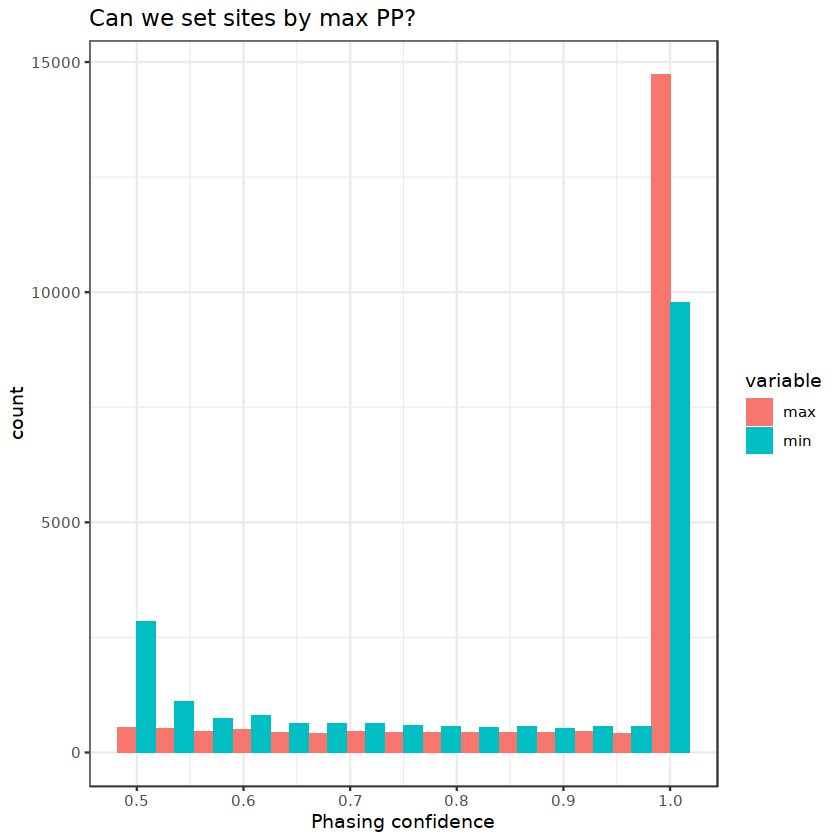

In [501]:
ggplot(melted_test, aes(x=value, fill=variable)) +
    geom_histogram(position="dodge",bins = 15) +
    xlab("Phasing confidence") +
    theme_bw() +
    ggtitle("Can we set sites by max PP?")

#aggr1 <- aggregate(PP ~ PS_rb, data = d, FUN = function(x) min(x)) #return(max(x)-min(x)))
#aggr2 <- aggregate(PP ~ PS_rb, data = d, FUN = function(x) max(x)) #return(max(x)-min(x)))


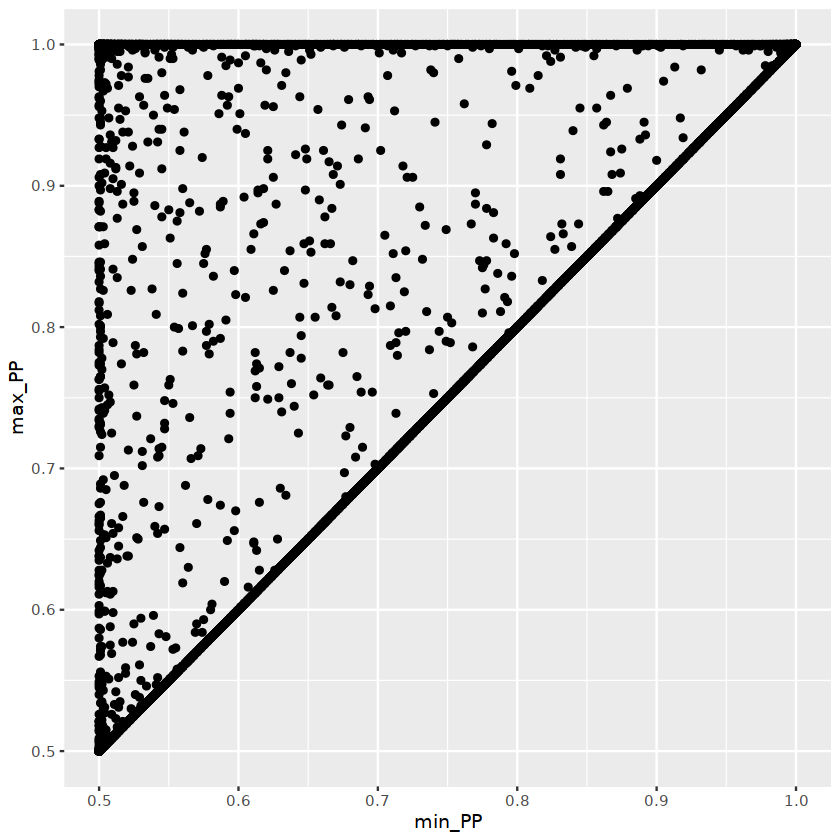

In [444]:
colnames(aggr1)[2] <- "min_PP"
colnames(aggr2)[2] <- "max_PP"
mrg <- merge(aggr1, aggr2)
ggplot(mrg, aes(x=min_PP, y=max_PP)) +
    geom_point()

In [435]:
sum(aggr$PP >= 0.45)/nrow(aggr)

[1] 0.1232623

In [347]:
d <- d[!is.na(d$PP)]

In [359]:
sites <- "/well/lindgren/UKBIOBANK/dpalmer/wes_200k/ukb_wes_qc/data/variants/08_final_qc.keep.variant_list"
wes_sites <- fread(sites)

In [372]:
sum(grepl(pattern = "chr21\\:",wes_sites$locus))

[1] 99883

In [373]:
dt <- d[d$locus %in% wes_sites$locus,]

In [384]:
head(dt)

locus,alleles,rsid,AC,AF,s,PP,GT,PS_rb,GT_rb
<chr>,<chr>,<chr>,<int>,<lgl>,<int>,<dbl>,<chr>,<int>,<chr>
chr21:10413663,"[""G"",""A""]",chr21:10413663:G:A,124,NA,3674182,1.000,0|1,10413663,1|0
chr21:10413663,"[""G"",""A""]",chr21:10413663:G:A,124,NA,4856056,0.787,1|0,10413663,1|0
chr21:10413663,"[""G"",""A""]",chr21:10413663:G:A,124,NA,5946258,0.998,0|1,10413663,1|0
chr21:10413748,"[""T"",""C""]",chr21:10413748:T:C,55,NA,5946258,0.522,1|0,10413663,0|1
chr21:10413783,"[""A"",""G""]",chr21:10413783:A:G,398327,NA,1691664,0.815,1|0,10413783,0|1
chr21:10413783,"[""A"",""G""]",chr21:10413783:A:G,398327,NA,3674182,0.519,1|0,10413663,1|0


In [382]:
variants <- length(unique(dt$rsid))
singletons <- sum(dt$AC == 1)
singletons_frac <- singletons / variants

In [383]:
variants; singletons; singletons_frac

[1] 31263

[1] 6342

[1] 0.2028596

In [348]:
samples <- unique(d$s)
sample <- samples[12]

In [349]:
ds <- d[d$s %in% sample,]
# get phased sets with at least two variants
ps <- ds$PS_rb
df_ps <- data.frame(table(ps))
ps <- df_ps$ps[df_ps$Freq > 1]



In [350]:
rev_gt <- function(gt){    
    stopifnot(gt %in% c("1|0", "0|1"))
    if (gt == "1|0") return("0|1") 
    else if (gt == "0|1") return("1|0") 
}

In [351]:
rev_gt(c("1|0","1|0"))

Warning message in if (gt == "1|0") return("0|1") else if (gt == "0|1") return("1|0"):
"the condition has length > 1 and only the first element will be used"


[1] "0|1"

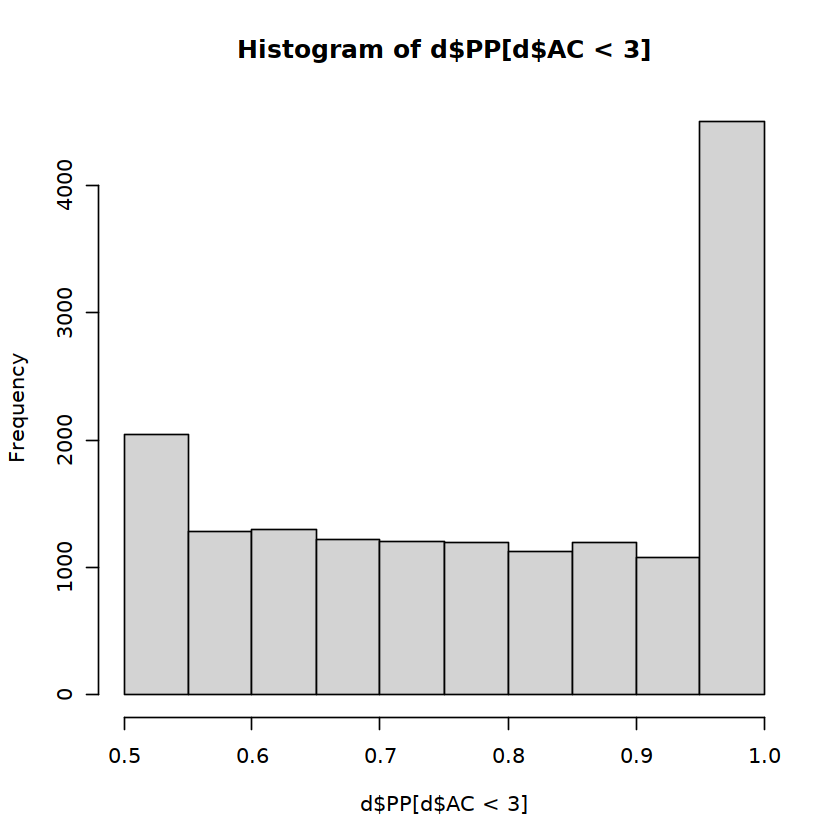

In [352]:
#hist(d$PP)
hist(d$PP[d$AC < 3])

In [331]:
result <- do.call(rbind, lapply(samples, function(sample){
    
    # get indiivual 
    ds <- d[d$s %in% sample,]
    ps <- ds$PS_rb
    df_ps <- data.frame(table(ps))
    ps <- df_ps$ps[df_ps$Freq > 1]
    
    dt <- do.call(rbind, lapply(ps, function(p){

        ds <- ds[ds$PS_rb %in% p]

        # get shapeit and whatshap genotypes\
        n <- length(ds$GT)
        shapeit_genotypes <- ds$GT
        whatshap_genotypes <- ds$GT_rb
        whatshap_genotypes_rev <- unlist(lapply(whatshap_genotypes, rev_gt))
        
        bool_ok <- (
            all(shapeit_genotypes == whatshap_genotypes) |
            all(shapeit_genotypes == whatshap_genotypes_rev)
        
        )
        
        correct <- sum(bool_ok)
        total <- length(bool_ok)
        return(data.frame(
            correct = correct,
            total = total,
            n_variants = n,
            pp_max = max(ds$PP),
            pp_min = min(ds$PP),
            pp_prod = prod(ds$PP),
            ps = p,
            sample = sample
        ))
        
    }))
    
    return(dt)
}))


In [207]:
breaks <- c(0, 0.5, 0.75, 0.80, 0.85, 0.90, 0.95, 0.99, 1)

In [208]:
result$pp_category <- cut(result$pp_prod, breaks = breaks)


In [221]:
mrg1 <- merge(
    aggregate(correct ~ pp_category, data = result, FUN = sum),
    aggregate(total ~ pp_category, data = result, FUN = sum)
    )

mrg2 <- aggregate(correct ~ pp_category, data = result, FUN = sd)
colnames(mrg2)[2] <- "correct_sd"
mrg <- merge(mrg1, mrg2)

In [222]:
mrg

pp_category,correct,total,correct_sd
<fct>,<int>,<int>,<dbl>
"(0,0.5]",157,198,0.4062338
"(0.5,0.75]",186,263,0.4559039
"(0.75,0.8]",31,40,0.4229021
"(0.8,0.85]",28,37,0.4349588
"(0.85,0.9]",46,50,0.2740475
"(0.9,0.95]",50,53,0.2332953
"(0.95,0.99]",73,81,0.3002057
"(0.99,1]",4717,4774,0.1086259


In [267]:
mrg$accuracy <- mrg$correct / mrg$total

In [268]:
title <- "Comparison of phasing (10K samples)"
subtitle <- "Errors bars are SD"

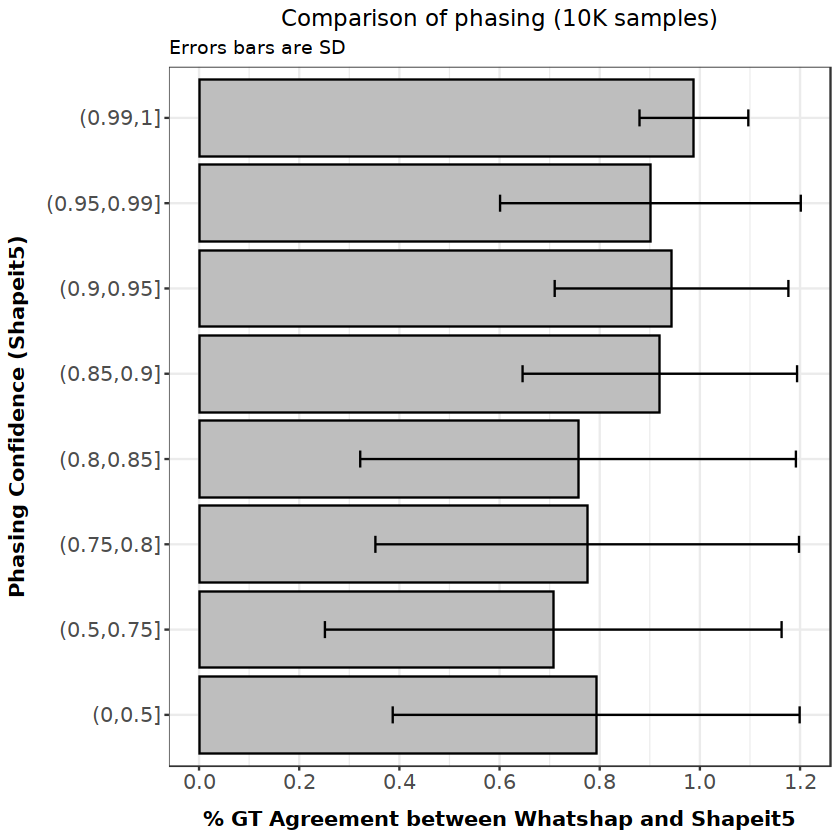

In [250]:
ggplot(mrg, aes(y=pp_category, x=accuracy, xmin=accuracy-correct_sd, xmax=accuracy+correct_sd)) +
    geom_bar(stat='identity', color = 'black', fill = "grey") + 
    geom_errorbar(width = 0.2) +
    theme_bw() +
    ggtitle(title, subtitle) +
    scale_x_continuous(breaks=scales::pretty_breaks(n=5)) +
    ylab("Phasing Confidence (Shapeit5)") +
    xlab("% GT Agreement between Whatshap and Shapeit5") +
    theme(
        legend.position = "top",
        axis.text=element_text(size=12),
        axis.title=element_text(size=12,face="bold"),
        axis.title.x = element_text(margin=ggplot2::margin(t=10)),
        axis.title.y = element_text(margin=ggplot2::margin(r=10)),
        plot.title = element_text(hjust=0.5)
    )


In [284]:
result$rank <- rank(result$pp_prod)

In [286]:
#plot(result$rank,)

In [291]:
#AUCBoot(pred, target, nboot = 10000, seed = NA, digits = NULL)
#x <- AUCBoot(result$pp_prod, result$correct, nboot = 10000, seed = NA, digits = NULL)
?rocit

Warning message in seq_len(head.end.idx):
"first element used of 'length.out' argument"
ERROR while rich displaying an object: Error in seq_len(head.end.idx): argument must be coercible to non-negative integer

Traceback:
1. FUN(X[[i]], ...)
2. tryCatch(withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
 .         return(NULL)
 .     prepare_content(is.raw(rpr), rpr)
 . }, error = error_handler), error = outer_handler)
3. tryCatchList(expr, classes, parentenv, handlers)
4. tryCatchOne(expr, names, parentenv, handlers[[1L]])
5. doTryCatch(return(expr), name, parentenv, handler)
6. withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
 .         return(NULL)
 .     prepare_conte

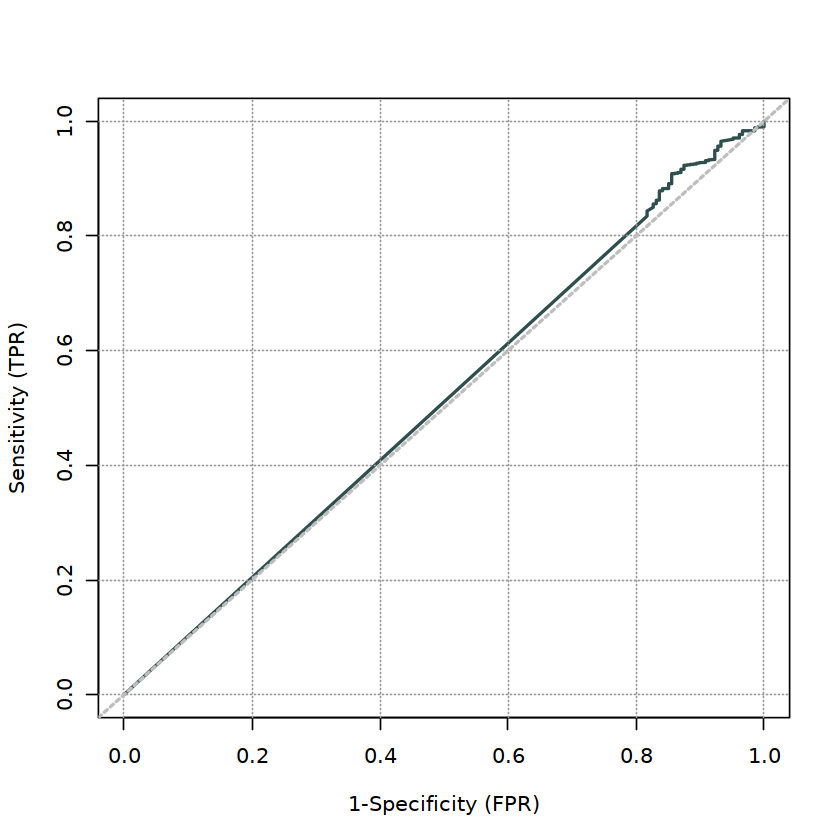

In [325]:
library(ROCit)
ROCit_obj <- rocit(score=sample(result$pp_prod),class=result$correct, method = "empirical")
plot(ROCit_obj, legend = FALSE, YIndex = FALSE)

[1]        Inf 1.00000000 0.99900000 0.99800100 0.99800000 0.99700300
  [7] 0.99700200 0.99700000 0.99600600 0.99600400 0.99600300 0.99600000
 [13] 0.99500999 0.99500400 0.99500000 0.99400900 0.99400800 0.99400500
 [19] 0.99400000 0.99301000 0.99300000 0.99201600 0.99200700 0.99200000
 [25] 0.99101800 0.99002500 0.99002100 0.99000900 0.99000000 0.98903000
 [31] 0.98900000 0.98803600 0.98800000 0.98700000 0.98604900 0.98600000
 [37] 0.98504400 0.98502600 0.98500000 0.98406400 0.98402800 0.98400000
 [43] 0.98307200 0.98300000 0.98208100 0.98200000 0.98109000 0.98108293
 [49] 0.98101800 0.98100000 0.98010000 0.98000000 0.97804000 0.97800000
 [55] 0.97700000 0.97619149 0.97614400 0.97612800 0.97600000 0.97500000
 [61] 0.97324227 0.97302600 0.97300000 0.97230929 0.97219600 0.97200000
 [67] 0.97100000 0.97000000 0.96919800 0.96903000 0.96825600 0.96628900
 [73] 0.96432400 0.96431500 0.96110800 0.96000000 0.95800000 0.95600000
 [79] 0.95452900 0.95355000 0.95300000 0.95254000 0.95200000 0.95132800
 [85] 0.95100000 0.95082739 0.95062500 0.95000000 0.94900000 0.94867600
 [91] 0.94746200 0.94653300 0.94300000 0.94215044 0.94200000 0.94090000
 [97] 0.93900000 0.93800000 0.93508900 0.93500000 0.93400000 0.93216000
[103] 0.93120900 0.93113400 0.93000000 0.92929600 0.92802600 0.92736900
[109] 0.92700000 0.92528400 0.92300000 0.92200000 0.92067840 0.92000000
[115] 0.91845000 0.91808100 0.91800000 0.91776400 0.91600000 0.91582400
[121] 0.91522400 0.91500000 0.91379200 0.91336000 0.91100000 0.91017600
[127] 0.91000000 0.90630400 0.90527600 0.90500000 0.90100000 0.89870400
[133] 0.89870300 0.89800000 0.89754600 0.89700000 0.89620400 0.89600000
[139] 0.89490000 0.89200000 0.88924900 0.88800000 0.88600000 0.88592000
[145] 0.88500000 0.88400000 0.88200000 0.88100000 0.87984400 0.87900000
[151] 0.87800000 0.87796900 0.87300000 0.87235600 0.87200000 0.87100000
[157] 0.87000000 0.86900000 0.86862400 0.86676100 0.86602300 0.86552318
[163] 0.86489900 0.86426800 0.86200000 0.86100000 0.85932900 0.85800000
[169] 0.85700000 0.85474200 0.85400000 0.85377600 0.85300000 0.84800000
[175] 0.84731400 0.84700000 0.84300000 0.84272400 0.84200000 0.84100000
[181] 0.83900000 0.83700000 0.83589689 0.83539600 0.83400000 0.83356900
[187] 0.82800000 0.82600000 0.82517400 0.82200000 0.82100000 0.82083600
[193] 0.82000000 0.81900000 0.81721600 0.81718200 0.81600000 0.81500000
[199] 0.81200000 0.80800000 0.80640400 0.80638800 0.80500000 0.80460900
[205] 0.80100000 0.79744900 0.79707000 0.79700000 0.79566400 0.79500000
[211] 0.79300000 0.79200000 0.78854400 0.78814400 0.78676900 0.78499600
[217] 0.78400000 0.78300000 0.78100000 0.77900000 0.77800000 0.77766000
[223] 0.77616000 0.77600000 0.77400000 0.77283400 0.77200000 0.77100000
[229] 0.76700000 0.76646400 0.76600000 0.76399500 0.76212900 0.76000000
[235] 0.75700000 0.75690000 0.75324600 0.75300000 0.75000000 0.74995600
[241] 0.74822500 0.74600000 0.74500000 0.74152300 0.74132100 0.74046000
[247] 0.73960000 0.73600000 0.73444900 0.73200000 0.73000000 0.72900000
[253] 0.72760900 0.72754273 0.72600000 0.72500000 0.72420100 0.72300000
[259] 0.72200000 0.72100000 0.72000000 0.71910400 0.71500000 0.71400000
[265] 0.71300000 0.71233600 0.71228700 0.71200000 0.71000000 0.70957800
[271] 0.70800000 0.70728100 0.70708500 0.70317600 0.70300000 0.70000000
[277] 0.69800000 0.69700000 0.69600000 0.69555600 0.69330600 0.69300000
[283] 0.69222400 0.69200000 0.69100000 0.69000000 0.68800000 0.68700000
[289] 0.68600000 0.68558400 0.68500000 0.68308200 0.68300000 0.68279600
[295] 0.68100000 0.68000808 0.67900000 0.67800000 0.67732900 0.67600000
[301] 0.67500000 0.67404100 0.67300000 0.67200000 0.67000000 0.66900000
[307] 0.66800000 0.66766200 0.66700000 0.66615402 0.66400000 0.66100000
[313] 0.66077631 0.65900000 0.65772100 0.65700000 0.65600000 0.65372800
[319] 0.65300000 0.65243200 0.65219828 0.65207800 0.65000000 0.64900000
[325] 0.64816600 0.64641600 0.64300000 0.64200000 0.64100000 0.63700000
[331] 0.63400000 0.63282000 0.62900000 0.6

In [106]:
dtop <- result[result$pp_prod > 0.999,]


In [107]:
sum(dtop$accuracy) / nrow(dtop)

[1] 0.5902613

In [13]:
args <- list(
    input_path="data/simulation/phenotypes/ukb_eur_h2_0.10_0.10_pi_0.50_0.00_K0.1_chr21",
    real_phenotype_path="data/phenotypes/filtered_covar_phenotypes_cts.tsv.gz",
    covars_keep="PC1,age"
)


In [14]:
print(args)
stopifnot(dir.exists(dirname(args$input_path)))
stopifnot(file.exists(args$real_phenotype_path))

$input_path
[1] "data/simulation/phenotypes/ukb_eur_h2_0.10_0.10_pi_0.50_0.00_K0.1_chr21"

$real_phenotype_path
[1] "data/phenotypes/filtered_covar_phenotypes_cts.tsv.gz"

$covars_keep
[1] "PC1,age"



In [15]:
# load phenotypes and covariates to keep
covars <- unlist(strsplit(args$covars_keep, split = ","))
d <- fread(args$real_phenotype_path)
d <- d[,colnames(d) %in% c("eid", covars), with = FALSE]
stopifnot(ncol(d) > 0 )

In [17]:
# load prefixes
bname <- basename(args$input_path)
dname <- dirname(args$input_path)
files <- list.files(dname, pattern = bname, full.names = TRUE)
if (length(files) == 0) stop(paste("no files with pattern",bname,"in directory",dname))
files <- files[!grepl('_entries',files)]
files <- files[!grepl('_phenos',files)]

In [26]:
# merge prefixes
lst <- lapply(files, function(f){
 id <- stringr::str_extract(basename(f),"[0-9]+_cols.tsv.gz")
 id <- gsub('_cols\\.tsv\\.gz','', id)
 d <- fread(f)
 colnames(d)[2:ncol(d)] <- paste0(colnames(d)[2:ncol(d)],'_', id)
 return(d)
})

In [28]:








# combine phentypes and each prefix file
reduced <- Reduce(merge, lst)
final <- merge(reduced, d, by.x = 's', by.y = 'eid', all.x = TRUE)

# add missing covariates
final$age2 <- final$age^2
final$sex_age <- final$age * final$sex

# write out
colnames(final)[colnames(final)=="s"] <- 'eid'

In [29]:
head(final)

eid,y_no_noise_H1_10,y_no_noise_H2_10,y_no_noise_sign_10,y_no_noise_H_10,y_10,case_10,y_no_noise_H1_1,y_no_noise_H2_1,y_no_noise_sign_1,⋯,y_no_noise_H1_9,y_no_noise_H2_9,y_no_noise_sign_9,y_no_noise_H_9,y_9,case_9,age,PC1,age2,sex_age
<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>,<int>,<dbl>,<dbl>,<int>
1000028,1.4036,1.4036,1,0.016287,1.9007,FALSE,1.1764,1.1764,1,⋯,0.0080978,0.0080978,1,0.0029685,0.38713,FALSE,45,-11.34000,2025,NA
1000034,1.4036,1.4036,1,0.016287,3.1105,FALSE,1.1764,1.1764,1,⋯,0.0080978,0.0080978,1,0.0029685,-0.94841,FALSE,61,-7.59207,3721,NA
1000087,1.4036,1.4036,1,0.016287,1.2653,FALSE,1.1764,1.1764,1,⋯,0.0080978,0.0080978,1,0.0029685,-0.34992,FALSE,65,-11.36170,4225,NA
1000162,1.4036,1.4036,1,0.016287,2.1335,FALSE,1.1764,1.1764,1,⋯,0.0080978,0.0080978,1,0.0029685,0.93719,FALSE,45,-11.43270,2025,NA
1000171,1.4036,1.4036,1,0.016287,2.5487,FALSE,1.1764,2.2550,1,⋯,0.3857700,-0.5112200,-1,-0.0029685,-0.39776,FALSE,61,-12.83620,3721,NA
1000196,1.4036,1.4036,1,0.016287,2.0018,FALSE,1.1764,1.1764,1,⋯,0.0080978,0.0080978,1,0.0029685,-0.31111,FALSE,66,-12.79490,4356,NA


In [39]:
nrow(final)

[1] 100000

In [98]:
A <- rnorm(1000)


In [99]:
B <- rnorm(1000, mean = A*0.3)
C <- rnorm(1000, mean = B*0.1)

In [100]:
D <- data.frame(A=A,B=B)

In [101]:
corr_fun <- function(data, idx)
{
  df <- data[idx, ]
  c(cor(df[,1], df[,2], method = 'pearson'))
}

In [102]:
test <- D[,c(1,2)]

In [103]:
bootstrap <- boot(test, cor, R = 1000)
bootstrap


ORDINARY NONPARAMETRIC BOOTSTRAP


Call:
boot(data = test, statistic = cor, R = 1000)


Bootstrap Statistics :
         original       bias    std. error
t1*  3.137805e-02 -0.032722767  0.03131987
t2* -3.764487e-05 -0.000877408  0.03096266

In [104]:
ci <- boot.ci(bootstrap)

Warning message in sqrt(tv[, 2L]):
"NaNs produced"
Warning message in sqrt(tv0[2L]):
"NaNs produced"
Warning message in norm.inter(t, adj.alpha):
"extreme order statistics used as endpoints"


In [105]:
ci

BOOTSTRAP CONFIDENCE INTERVAL CALCULATIONS
Based on 1000 bootstrap replicates

CALL : 
boot.ci(boot.out = bootstrap)

Intervals : 
Level      Normal              Basic             Studentized     
95%   ( 0.0027,  0.1255 )   ( 0.0028,  0.1250 )   (    NaN,     NaN )  

Level     Percentile            BCa          
95%   (-0.0622,  0.0599 )   ( 0.0032,  0.1123 )  
Calculations and Intervals on Original Scale
Some BCa intervals may be unstable

In [107]:
list.files("data/prs/scores", pattern = "chrom\\.txt\\.gz", full.names = TRUE)

[1] "data/prs/scores/AD_combined_pgs_chrom.txt.gz"                            
 [2] "data/prs/scores/AD_combined_primary_care_pgs_chrom.txt.gz"               
 [3] "data/prs/scores/Alanine_aminotransferase_residual_int_pgs_chrom.txt.gz"  
 [4] "data/prs/scores/Albumin_residual_int_pgs_chrom.txt.gz"                   
 [5] "data/prs/scores/Alkaline_Phosphatase_residual_int_pgs_chrom.txt.gz"      
 [6] "data/prs/scores/Apolipoprotein_A_residual_int_pgs_chrom.txt.gz"          
 [7] "data/prs/scores/Apolipoprotein_B_residual_int_pgs_chrom.txt.gz"          
 [8] "data/prs/scores/Aspartate_aminotransferase_residual_int_pgs_chrom.txt.gz"
 [9] "data/prs/scores/BC_combined_pgs_chrom.txt.gz"                            
[10] "data/prs/scores/BC_combined_primary_care_pgs_chrom.txt.gz"               
[11] "data/prs/scores/BMI_imp_int_pgs_chrom.txt.gz"                            
[12] "data/prs/scores/BMI_int_pgs_chrom.txt.gz"                                
[13] "data/prs/scores/CAD_combined_pgs_chrom.txt.gz"                           
[14] "data/prs/scores/CAD_combined_primary_care_pgs_chrom.txt.gz"              
[15] "data/prs/scores/CC_combined_pgs_chrom.txt.gz"                            
[16] "data/prs/scores/CC_combined_primary_care_pgs_chrom.txt.gz"               
[17] "data/prs/scores/COPD_combined_pgs_chrom.txt.gz"                          
[18] "data/prs/scores/COPD_combined_primary_care_pgs_chrom.txt.gz"             
[19] "data/prs/scores/C_reactive_Protein_residual_int_pgs_chrom.txt.gz"        
[20] "data/prs/scores/Calcium_residual_int_pgs_chrom.txt.gz"                   
[21] "data/prs/scores/Cholesterol_residual_int_pgs_chrom.txt.gz"               
[22] "data/prs/scores/Creatinine_Serum_residual_int_pgs_chrom.txt.gz"          
[23] "data/prs/scores/Creatinine_Urine_residual_int_pgs_chrom.txt.gz"          
[24] "data/prs/scores/DEP_combined_pgs_chrom.txt.gz"                           
[25] "data/prs/scores/DEP_combined_primary_care_pgs_chrom.txt.gz"              
[26] "data/prs/scores/EP_combined_pgs_chrom.txt.gz"                            
[27] "data/prs/scores/EP_combined_primary_care_pgs_chrom.txt.gz"               
[28] "data/prs/scores/Gamma_glutamyltransferase_residual_int_pgs_chrom.txt.gz" 
[29] "data/prs/scores/Glucose_residual_int_pgs_chrom.txt.gz"                   
[30] "data/prs/scores/HDL_Cholesterol_residual_int_pgs_chrom.txt.gz"           
[31] "data/prs/scores/HbA1c_residual_int_pgs_chrom.txt.gz"                     
[32] "data/prs/scores/IGF_1_residual_int_pgs_chrom.txt.gz"                     
[33] "data/prs/scores/NAFLD_combined_pgs_chrom.txt.gz"                         
[34] "data/prs/scores/NAFLD_combined_primary_care_pgs_chrom.txt.gz"            
[35] "data/prs/scores/Phosphate_residual_int_pgs_chrom.txt.gz"                 
[36] "data/prs/scores/Potassium_Urine_residual_int_pgs_chrom.txt.gz"           
[37] "data/prs/scores/RF_acute_combined_pgs_chrom.txt.gz"                      
[38] "data/prs/scores/RF_acute_combined_primary_care_pgs_chrom.txt.gz"         
[39] "data/prs/scores/RF_chronic_combined_pgs_chrom.txt.gz"                    
[40] "data/prs/scores/RF_chronic_combined_primary_care_pgs_chrom.txt.gz"       
[41] "data/prs/scores/RF_combined_pgs_chrom.txt.gz"                            
[42] "data/prs/scores/RF_combined_primary_care_pgs_chrom.txt.gz"               
[43] "data/prs/scores/Sodium_Urine_residual_int_pgs_chrom.txt.gz"              
[44] "data/prs/scores/Testosterone_residual_int_pgs_chrom.txt.gz"              
[45] "data/prs/scores/Total_Protein_residual_int_pgs_chrom.txt.gz"             
[46] "data/prs/scores/Triglyceride_residual_int_pgs_chrom.txt.gz"              
[47] "data/prs/scores/Urea_residual_int_pgs_chrom.txt.gz"                      
[48] "data/prs/scores/Vitamin_D_residual_int_pgs_chrom.txt.gz"                 
[49] "data/prs/scores/WHR_adj_BMI_int_pgs_chrom.txt.gz"                        
[50] "data/prs/scores/WHR_int_pgs_chrom.txt.gz"                                
[

In [114]:
d <- fread("data/prs/scores/standing_height_int_pgs_chrom.txt.gz")
idx <- sample(1:nrow(d), size = 10000)
d <- d[idx,]

In [40]:
boot_cor_ci <- function(data, col1, col2, n = 1000, method='pearson'){
    
    data <- data.frame(data)
    b <- boot(data, 
      statistic = function(data, i) {
        cor(data[i, col1], data[i, col2], method='pearson')
      },
      R = n
    )
    
    out <- data.frame(t(matrix(quantile(b$t, probs = c(0.025, 0.975)))))
    colnames(out) <- c("ci0025","ci975")
    out$mean <- mean(b$t)
    out$col1 <- col1
    out$col2 <- col2
    return(out)
}

In [81]:
ztest <- function(d, a1, a2){
    f <- as.formula(paste0(a1, "~", a2))
    fit <- lm(f, data = d)
    coef <- coefficients(summary(fit))
    est <- coef[2,1]
    stderr <- coef[2,2]
    z <- est / stderr
    pvalue <- 2 * pnorm(abs(z), lower.tail = FALSE)
    return(pvalue)
}



[1] 0.9388194

In [13]:
b3 <- boot(d, 
  statistic = function(data, i) {
    cor(d[i, "chr1"], data[i, "chr3"], method='pearson')
  },
  R = 1000
)


In [117]:
autosomes <- paste0("chr",1:22)
M <-do.call(rbind, lapply(autosomes, function(a1){
    do.call(rbind, lapply(autosomes, function(a2){
            if (a1 != a2) {data.frame(boot_cor_ci(d, a1, a2), pvalue = ztest(d, a1, a2))}
    }))
}))


In [118]:
head(M)

,ci0025,ci975,mean,col1,col2,pvalue
,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<dbl>
1,-0.0130044033,0.02764168,0.0066489628,chr1,chr2,0.5249405
2,0.0009063669,0.04140608,0.0215437831,chr1,chr3,0.0304564
3,-0.0135066077,0.02561865,0.0060220516,chr1,chr4,0.5768577
4,-0.0162528394,0.02384607,0.0047902483,chr1,chr5,0.6319898
5,-0.0204606134,0.01787070,-0.0008162445,chr1,chr6,0.9317672
6,-0.0081789888,0.03028332,0.0110643683,chr1,chr7,0.2692504


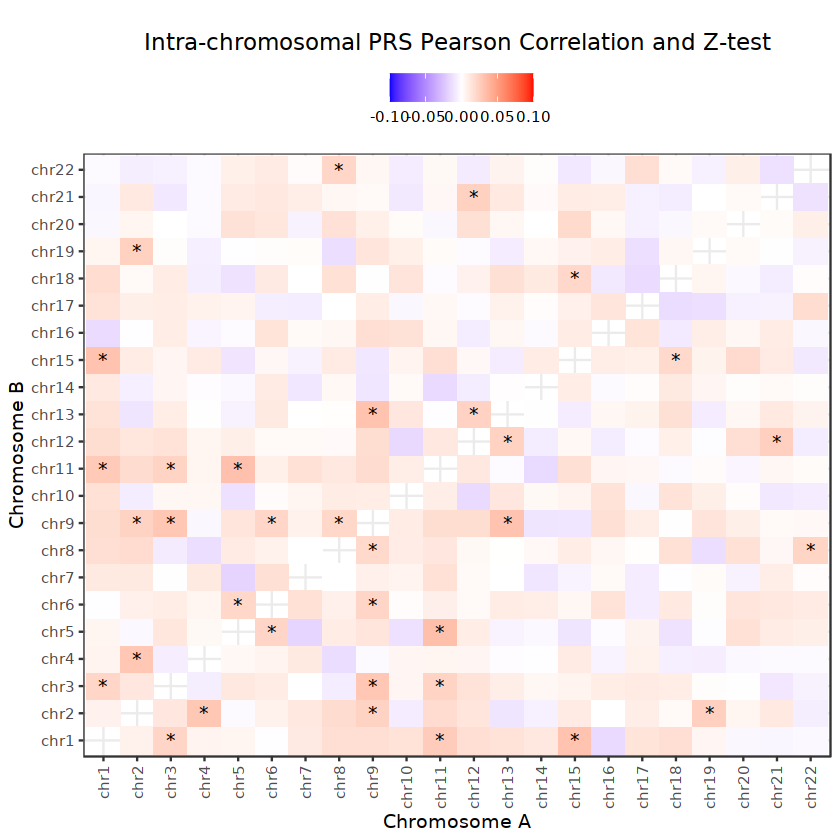

In [168]:
M$col1 <- factor(M$col1, levels = autosomes)
M$col2 <- factor(M$col2, levels = autosomes)
M$labels <- ifelse(M$pvalue < 0.05/(22*11-22), '**', ifelse(M$pvalue < 0.05 , '*',''))
ggplot(M, aes(x=col1, y=col2, fill=mean, label = labels)) +
    geom_tile() +
    geom_text() +
    theme_bw() +
    ylab("Chromosome B") +
    xlab("Chromosome A") +
    labs(fill = "") +
    scale_fill_gradient2(low="blue", mid = 'white', high='red', limits = c(-0.1,0.1)) +
    theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust=1),
          legend.position = "top",
          plot.title = element_text(hjust = 0.5)
         ) +
    ggtitle(paste0("\nIntra-chromosomal PRS Pearson Correlation and Z-test"))

In [110]:
fit <- lm(chr11 ~ chr1, data = d)

In [113]:
cor(d$chr11, d$chr1)

[1] 0.01782171

In [33]:
args <- list(
    in_prefix="data/phased/wes_union_calls/trimmed/ukb_eur_wes_union_calls_200k_chr21_trim"
)


In [37]:
files <- list.files(dirname(args$in_prefix), pattern = basename(args$in_prefix), full.names = TRUE)
files
#files <- files[grepl(".vcf.bgz$", files)]
#files
#stopifnot(length(files) > 0)

[1] "data/phased/wes_union_calls/trimmed/ukb_eur_wes_union_calls_200k_chr21_trims.txt"

In [21]:
chunks <- stringr::str_extract(files,"[0-9]+of[0-9]+")
chunks <- data.frame(do.call(rbind, strsplit(chunks, "of")))
chunks$X1 <- as.numeric(chunks$X1)
chunks$X2 <- as.numeric(chunks$X2)

In [32]:
stopifnot(length(unique(chunks$X2)) == 1)
stopifnot(length(unique(chunks$X1)) == nrow(chunks))

In [24]:
out <- files[order(chunks$X1)]

In [26]:
paste(out, collapse = " ")

[1] "data/phased/wes_union_calls/trimmed/ukb_eur_wes_union_calls_200k_chr1_trim.1of14.vcf.bgz data/phased/wes_union_calls/trimmed/ukb_eur_wes_union_calls_200k_chr1_trim.2of14.vcf.bgz data/phased/wes_union_calls/trimmed/ukb_eur_wes_union_calls_200k_chr1_trim.3of14.vcf.bgz data/phased/wes_union_calls/trimmed/ukb_eur_wes_union_calls_200k_chr1_trim.4of14.vcf.bgz data/phased/wes_union_calls/trimmed/ukb_eur_wes_union_calls_200k_chr1_trim.5of14.vcf.bgz data/phased/wes_union_calls/trimmed/ukb_eur_wes_union_calls_200k_chr1_trim.6of14.vcf.bgz data/phased/wes_union_calls/trimmed/ukb_eur_wes_union_calls_200k_chr1_trim.7of14.vcf.bgz data/phased/wes_union_calls/trimmed/ukb_eur_wes_union_calls_200k_chr1_trim.8of14.vcf.bgz data/phased/wes_union_calls/trimmed/ukb_eur_wes_union_calls_200k_chr1_trim.9of14.vcf.bgz data/phased/wes_union_calls/trimmed/ukb_eur_wes_union_calls_200k_chr1_trim.10of14.vcf.bgz data/phased/wes_union_calls/trimmed/ukb_eur_wes_union_calls_200k_chr1_trim.11of14.vcf.bgz data/phased/wes_union_calls/trimmed/ukb_eur_wes_union_calls_200k_chr1_trim.12of14.vcf.bgz data/phased/wes_union_calls/trimmed/ukb_eur_wes_union_calls_200k_chr1_trim.13of14.vcf.bgz data/phased/wes_union_calls/trimmed/ukb_eur_wes_union_calls_200k_chr1_trim.14of14.vcf.bgz"